# Clustering evaluation and comparison

The key ideas:
- how to evaluate clustering with ground truth
- why accuracy is not appropriate for clustering labels
- how to evaluate clustering without ground truth
- why the silhouette score can be misleading
- why clustering is ultimately a qualitative/exploratory task
- a concise comparison of k-means, agglomerative clustering, and DBSCAN

# 1. Imports

In [28]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons, load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    adjusted_rand_score,
    accuracy_score,
    silhouette_score
)
from sklearn.decomposition import PCA

# 2. Main idea
It is much harder to evaluate clustering than supervised learning.

- In clustering, we usually **do not know the correct labels in advance**.
- Even when we do have labels for a toy example, clustering labels themselves are **arbitrary**.
- A clustering can be **mathematically stable** but still not **semantically meaningful**.

So it is important to know about what we can and cannot conclude from clustering results.

# 3. Evaluating with ground truth: Adjusted Rand Index (ARI)

When a reference labeling is available, one of the most useful clustering metrics is the adjusted rand index (ARI).

ARI measures how similar two partitions are:
- ARI=1.0 -> perfect agreement
- ARI=0 -> chance-level agreement
- it is **invariant to label names**

The last point is crucial: in clustering, label 0 and label 1 have no intrinsic meaning.

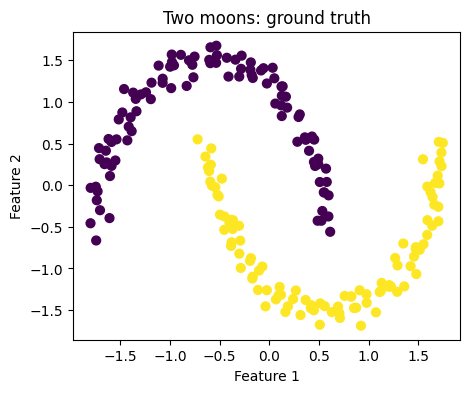

In [29]:
X, y = make_moons(n_samples=200, noise=0.05, random_state=0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

plt.figure(figsize=(5, 4))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=40)
plt.title("Two moons: ground truth")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

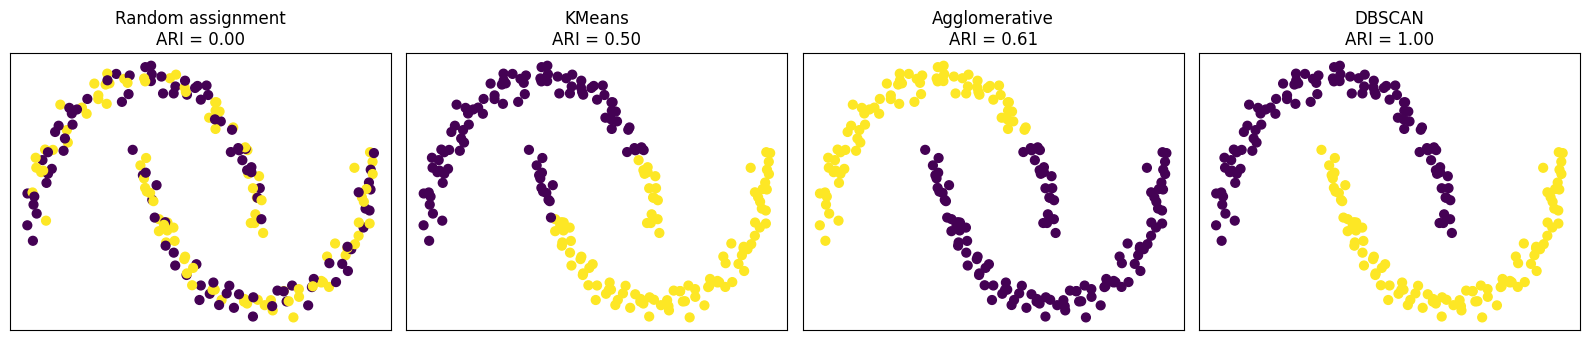

In [30]:
rng = np.random.RandomState(0)

algorithms = {
    "Random assignment": rng.randint(0, 2, size=len(X_scaled)),
    "KMeans": KMeans(n_clusters=2, random_state=0).fit_predict(X_scaled),
    "Agglomerative": AgglomerativeClustering(n_clusters=2).fit_predict(X_scaled),
    "DBSCAN": DBSCAN().fit_predict(X_scaled)
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), subplot_kw={"xticks":(), "yticks":()})

for ax, (name, clusters) in zip(axes, algorithms.items()):
    ari = adjusted_rand_score(y, clusters)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=40)
    ax.set_title(f"{name}\nARI = {ari:.2f}")
    
plt.tight_layout()
plt.show()
    

- A random partition should get a score near 0
- DBSCAN often does best on two moons because it can capture curved shapes
- k-means and Ward-style agglomerative clustering tend to prefer compact/convex clusters, so they may miss the true moon structure.

### `accuracy_score` is wrong for clustering labels

A common mistake is to compare clustering labels to ground-truth labels using accuracy.

This is wrong because cluster labels are **permutation-invariant**.

For example, these two labelings represent the **same clustering**:

- `[0, 0, 1, 1, 0]`
- `[1, 1, 0, 0, 1]`

Only the **grouping structure** matters, not the numeric label names.




In [31]:
clusters1 = [0, 0, 1, 1, 0]
clusters2 = [1, 1, 0, 0, 1]

print(f"Accuracy: {accuracy_score(clusters1, clusters2):.2f}")
print(f"ARI:      {adjusted_rand_score(clusters1, clusters2):.2f}")


Accuracy: 0.00
ARI:      1.00


# 4. Evaluating clustering **without** ground truth: silhouette score

In real applications, the true clustering is usually unknown.

A common internal metric is the **silhouette score**, which measures:

- how close each point is to points in its own cluster
- how far it is from points in other clusters

### Range
- close to **1** → clusters are compact and well separated
- around **0** → overlapping clusters
- below **0** → poor assignment

Silhouette favors **compact clusters**, so it may not reward the clustering we actually prefer.

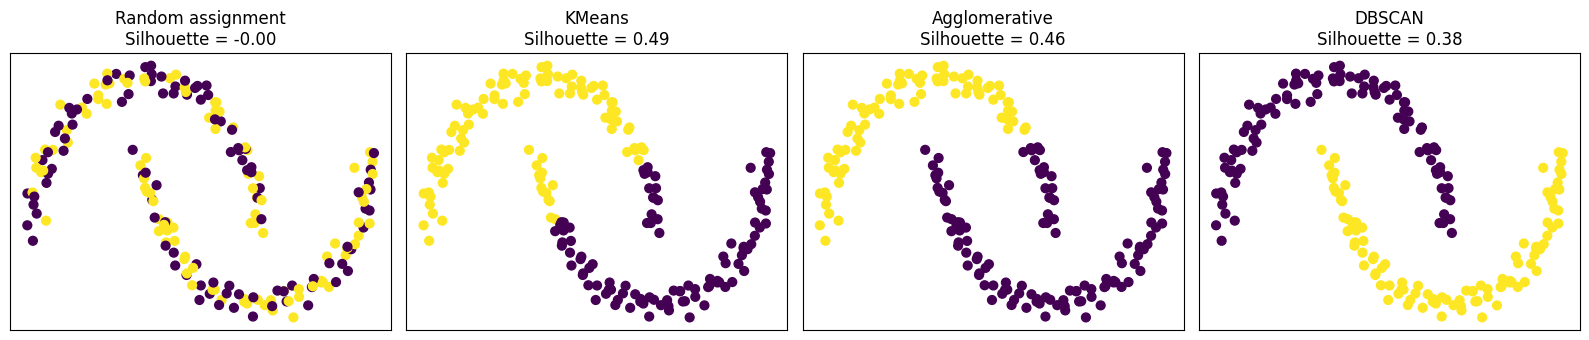

In [32]:
rng = np.random.RandomState(0)

algorithms = {
    "Random assignment": rng.randint(0, 2, size=len(X_scaled)),
    "KMeans": KMeans(n_clusters=2, random_state=0, n_init=10).fit_predict(X_scaled),
    "Agglomerative": AgglomerativeClustering(n_clusters=2).fit_predict(X_scaled),
    "DBSCAN": DBSCAN().fit_predict(X_scaled),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), subplot_kw={"xticks": (), "yticks": ()})

for ax, (name, clusters) in zip(axes, algorithms.items()):
    score = silhouette_score(X_scaled, clusters)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, s=40)
    ax.set_title(f"{name}\nSilhouette = {score:.2f}")

plt.tight_layout()
plt.show()

### Why silhouette can be misleading

On two moons, **k-means** may get a relatively high silhouette score even though its partition is less faithful to the actual moon shapes.

Why?

Because silhouette prefers:

- clusters that are **compact**
- clusters that are **well separated in Euclidean space**

But the true clusters here are **curved manifolds**, not spherical blobs.

### Important lesson
A high internal score does **not** necessarily mean the clustering captures the structure you care about.

### Robustness is often more informative than a single score

A clustering is more convincing if it is **stable** across:

- small perturbations of the data
- nearby parameter settings
- repeated runs

This idea is often called **robustness-based evaluation**.

scikit-learn does not provide a full built-in robustness framework for clustering, but you can still inspect it manually by varying parameters.


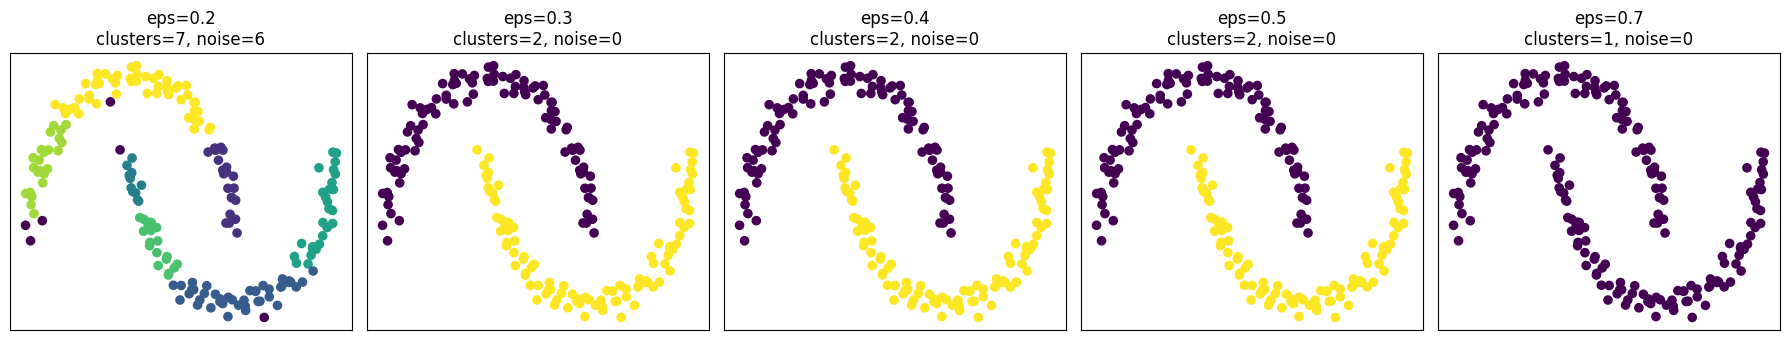

In [33]:
eps_values = [0.20, 0.30, 0.40, 0.50, 0.70]

fig, axes = plt.subplots(1, len(eps_values), figsize=(18, 3.5), subplot_kw={"xticks": (), "yticks": ()})

for ax, eps in zip(axes, eps_values):
    labels = DBSCAN(eps=eps).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, s=35)
    ax.set_title(f"eps={eps}\nclusters={n_clusters}, noise={n_noise}")

plt.tight_layout()
plt.show()

### Interpretation

This small experiment shows why DBSCAN needs careful tuning:

- **smaller `eps`** → more fragmented clusters, more noise
- **larger `eps`** → clusters merge together
- a useful clustering should ideally be **reasonably stable** over a sensible parameter range

This is often a more practical line of thought than trusting a single metric.

# 5. Comparison of the three algorithms

### k-means
**Strengths**

- fast and simple
- works well for compact clusters
- each cluster has a clear **centroid / mean**

**Weaknesses**
- requires choosing `n_clusters`
- struggles with non-convex shapes
- no notion of noise points

---
### Agglomerative clustering
**Strengths**
- builds a **hierarchy** of partitions
- useful when you want to inspect merges at different granularities
- flexible linkage choices

**Weaknesses**
- usually still prefers compact structure (especially Ward linkage)
- no direct notion of noise
- less scalable than k-means on very large data

---
### DBSCAN
**Strengths**
- can find **arbitrary-shaped clusters**
- naturally identifies **noise / outliers**
- does not require setting the number of clusters directly

**Weaknesses**
- sensitive to `eps` and `min_samples`
- can struggle with varying densities
- cluster labels may include `-1` for noise, which needs careful handling
